# Đánh giá các Giải thuật Machine Learning trong Hệ gợi ý (Movie RecSys)

Jupyter Notebook này thực hiện nghiên cứu, thực nghiệm và đánh giá chi tiết các thuật toán Học máy truyền thống (Traditional Machine Learning) áp dụng cho hệ thống gợi ý phim trên tập dữ liệu **MovieLens Small** (`ml-latest-small`).

Nội dung nghiên cứu dựa trên các hướng dẫn lý thuyết tại tệp [evaluation/machine_learning/README.md](file:///d:/Projects/movie-recsys/evaluation/machine_learning/README.md) và phân tích đặc điểm dữ liệu tại [evaluation/eda/eda_analysis.ipynb](file:///d:/Projects/movie-recsys/evaluation/eda/eda_analysis.ipynb).

---

### Mục tiêu nghiên cứu:
1. **Tiền xử lý và Thiết lập Pipeline**: Chia tập dữ liệu Train/Test và xây dựng các hàm đo lường chất lượng:
   * **Chỉ số sai số (Regression Metrics)**: RMSE, MAE.
   * **Chỉ số xếp hạng (Ranking Metrics)**: Precision@K, Recall@K, NDCG@K.
2. **Lọc cộng tác dựa trên lân cận (Memory-Based Collaborative Filtering)**:
   * User-based Collaborative Filtering (Cosine vs. Pearson similarity).
   * Item-based Collaborative Filtering (Cosine vs. Pearson similarity).
3. **Phân rã ma trận (Model-Based Matrix Factorization - MF)**:
   * Singular Value Decomposition (SVD).
   * SVD++ (incorporate implicit feedback).
   * Non-Negative Matrix Factorization (NMF).
4. **Lọc dựa trên nội dung (Content-Based Filtering)**:
   * Sử dụng đặc trưng thể loại phim (Genres) được biểu diễn bằng vector TF-IDF để đề xuất dựa trên sở thích người dùng.
5. **Factorization Machines (FM)**:
   * Xây dựng lớp mô hình FM từ đầu bằng NumPy, tối ưu bằng SGD, tích hợp thêm thông tin phụ (Movie Genres) để vượt qua giới hạn của MF truyền thống.
6. **Đánh giá và so sánh thực nghiệm**:
   * Tổng hợp hiệu năng của các mô hình thông qua bảng số liệu và biểu đồ trực quan.
   * Thảo luận về các Use Cases thực tế, vấn đề Cold Start và Scalability.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, SVD, SVDpp, NMF, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split
from collections import defaultdict

# Configure visualization styles
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Thư viện được tải thành công!")

Thư viện được tải thành công!


## Phần 1: Tải và Khám phá Dữ liệu

Dữ liệu được tải từ thư mục `../../data/ml-latest-small/` bao gồm:
* `ratings.csv`: Chứa ratings từ người dùng (userId, movieId, rating, timestamp).
* `movies.csv`: Chứa thông tin phim (movieId, title, genres).


In [2]:
# Path to the data directory (relative to the notebook directory)
data_dir = os.path.join("..", "..", "data", "ml-latest-small")

# Read ratings and movies files
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))
movies = pd.read_csv(os.path.join(data_dir, "movies.csv"))

print(f"Tổng số tương tác (ratings): {len(ratings):,}")
print(f"Số lượng người dùng duy nhất (userId): {ratings['userId'].nunique():,}")
print(f"Số lượng bộ phim duy nhất (movieId): {ratings['movieId'].nunique():,}")
print(f"Mật độ ma trận tương tác (Sparsity): {100 * (1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())):.2f}%")

display(ratings.head(3))
display(movies.head(3))

Tổng số tương tác (ratings): 100,836
Số lượng người dùng duy nhất (userId): 610
Số lượng bộ phim duy nhất (movieId): 9,724
Mật độ ma trận tương tác (Sparsity): 98.30%


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


## Phần 2: Định nghĩa Evaluation Metrics (Các Chỉ số Đánh giá)

Để đánh giá một hệ gợi ý một cách toàn diện, chúng ta cần dùng cả chỉ số sai số dự đoán điểm số và chỉ số xếp hạng danh sách:

### 2.1 Chỉ số sai số (Regression Metrics):
Thích hợp cho bài toán dự đoán ratings điểm số (Explicit Feedback):
* **Root Mean Squared Error (RMSE):** Phạt nặng hơn các sai lệch lớn.
  $$RMSE = \sqrt{\frac{1}{|T|} \sum_{(u,i) \in T} (r_{u,i} - \hat{r}_{u,i})^2}$$
* **Mean Absolute Error (MAE):** Trị tuyệt đối sai số trung bình.
  $$MAE = \frac{1}{|T|} \sum_{(u,i) \in T} |r_{u,i} - \hat{r}_{u,i}|$$

### 2.2 Chỉ số xếp hạng danh sách (Ranking Metrics):
Thích hợp cho bài toán Top-K recommendations, đo lường sự hài lòng của người dùng khi nhận được một danh sách gợi ý $K$ sản phẩm:
* **Precision@K:** Tỷ lệ phim được gợi ý thực sự có liên quan (ví dụ điểm số thực tế $\ge 3.5$) nằm trong Top-K gợi ý.
  $$Precision@K = \frac{\text{Số phim liên quan gợi ý trúng trong Top-K}}{K}$$
* **Recall@K:** Tỷ lệ phim liên quan của người dùng tìm thấy được trong Top-K gợi ý.
  $$Recall@K = \frac{\text{Số phim liên quan gợi ý trúng trong Top-K}}{\text{Tổng số phim liên quan trong tập Test của user}}$$
* **NDCG@K (Normalized Discounted Cumulative Gain):** Đánh giá vị trí xếp hạng. Phim có liên quan nằm ở vị trí càng cao thì điểm NDCG càng cao.
  $$DCG@K = \sum_{i=1}^K \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$
  $$NDCG@K = \frac{DCG@K}{IDCG@K}$$
  *(Trong đó $rel_i$ là điểm đánh giá thực tế của phim ở vị trí gợi ý thứ $i$. Nếu điểm đánh giá $< 3.5$ (không liên quan) thì $rel_i = 0$. $IDCG@K$ là giá trị DCG lý tưởng nhất khi danh sách được sắp xếp tối ưu theo mức liên quan).*


In [3]:
def precision_recall_ndcg_at_k(predictions, k=10, threshold=3.5):
    """
    Tính toán Precision@K, Recall@K và NDCG@K từ danh sách dự đoán của thư viện Surprise.
    predictions: Danh sách đối tượng prediction từ Surprise.
    """
    # Map predictions to each user
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}
    ndcgs = {}

    for uid, user_ratings in user_est_true.items():
        # Sắp xếp các sản phẩm theo điểm dự đoán giảm dần
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Số lượng phim thực sự liên quan trong tập test của user đó (điểm >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Cắt lấy Top-K gợi ý
        top_k = user_ratings[:k]

        # Số lượng phim liên quan trong Top-K gợi ý
        n_rel_and_rec_in_k = sum((true_r >= threshold) for (_, true_r) in top_k)

        # Precision@K: Tỷ lệ phim liên quan trong Top-K gợi ý
        precisions[uid] = n_rel_and_rec_in_k / k if k > 0 else 0

        # Recall@K: Tỷ lệ phim liên quan được gợi ý so với tổng số phim liên quan thực tế
        recalls[uid] = n_rel_and_rec_in_k / n_rel if n_rel > 0 else 0

        # NDCG@K
        dcg = 0.0
        for i, (_, true_r) in enumerate(top_k):
            # Nếu bộ phim thực sự có liên quan, tính độ liên quan là true_r hoặc nhị phân (1)
            # Ở đây ta dùng định nghĩa nhị phân: rel = 1 nếu true_r >= threshold, ngược lại 0
            rel = 1 if true_r >= threshold else 0
            dcg += (2**rel - 1) / np.log2(i + 2)

        # IDCG@K: Sắp xếp các rating thực tế trong tập test giảm dần, lấy top K
        test_ratings = [true_r for (_, true_r) in user_ratings]
        test_ratings.sort(reverse=True)
        idcg_top_k = test_ratings[:k]
        
        idcg = 0.0
        for i, true_r in enumerate(idcg_top_k):
            rel = 1 if true_r >= threshold else 0
            idcg += (2**rel - 1) / np.log2(i + 2)

        ndcgs[uid] = dcg / idcg if idcg > 0 else 0.0

    # Trả về giá trị trung bình trên tất cả người dùng
    mean_precision = sum(p for p in precisions.values()) / len(precisions) if precisions else 0
    mean_recall = sum(r for r in recalls.values()) / len(recalls) if recalls else 0
    mean_ndcg = sum(n for n in ndcgs.values()) / len(ndcgs) if ndcgs else 0

    return mean_precision, mean_recall, mean_ndcg

print("Định nghĩa hàm đo lường thành công!")

Định nghĩa hàm đo lường thành công!


## Phần 3: Lọc Cộng Tác dựa trên Lân Cận (Memory-Based Collaborative Filtering)

Nhóm lọc cộng tác dựa trên lân cận tính toán độ tương đồng giữa User-User hoặc Item-Item.
Ta sẽ đánh giá các thuật toán KNN với hai phương pháp tiếp cận chính:
1.  **User-based Collaborative Filtering**:
    *   **Mục tiêu**: Dự đoán đánh giá của người dùng $u$ cho phim $i$ bằng cách tìm nhóm các người dùng có sở thích tương đồng (lân cận) với $u$.
    *   **Tại sao cần**: Thích hợp khi hệ thống muốn tạo sự đa dạng, gợi ý các bộ phim thuộc thể loại mới mà người dùng chưa từng xem nhưng được nhóm lân cận ưa thích.
    *   **Ứng dụng**: Phổ biến trong mạng xã hội hoặc hệ thống gợi ý tin tức nơi mối quan hệ xã hội giữa những người dùng tương đồng rất bền chặt.
2.  **Item-based Collaborative Filtering**:
    *   **Mục tiêu**: Dự đoán đánh giá của người dùng $u$ cho phim $i$ bằng cách dựa trên sự tương đồng giữa phim $i$ và các phim khác mà $u$ từng đánh giá cao trong quá khứ.
    *   **Tại sao cần**: Do số lượng sản phẩm thường ổn định hơn số lượng người dùng (ít biến động sở thích hơn), ma trận tương đồng Item-Item có thể tính toán trước (offline) hiệu quả, cải thiện tốc độ và khả năng mở rộng.
    *   **Ứng dụng**: Hiển thị danh mục "Các phim tương tự" trên trang thông tin chi tiết phim (Netflix, IMDb).

Độ tương đồng giữa hai thực thể được đo lường bằng các công thức:
* **User-based CF (Cosine vs. Pearson similarity)**:
  $$sim(u, v) = \frac{\sum_{i} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)}{\sqrt{\sum (r_{u,i} - \bar{r}_u)^2} \sqrt{\sum (r_{v,i} - \bar{r}_v)^2}}$$
* **Item-based CF (Cosine vs. Pearson similarity)**:
  $$sim(i, j) = \frac{\mathbf{d}_i \cdot \mathbf{d}_j}{\|\mathbf{d}_i\| \|\mathbf{d}_j\|}$$


In [4]:
# Thiết lập Reader và Dataset của Surprise
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Chia tập Train/Test theo tỉ lệ 80/20
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

# Khởi tạo bảng lưu trữ kết quả so sánh
results = []

# Cấu hình các tham số KNN để thử nghiệm
knn_configs = [
    {"name": "User-Based KNN (Cosine)", "user_based": True, "similarity": "cosine"},
    {"name": "User-Based KNN (Pearson)", "user_based": True, "similarity": "pearson"},
    {"name": "Item-Based KNN (Cosine)", "user_based": False, "similarity": "cosine"},
    {"name": "Item-Based KNN (Pearson)", "user_based": False, "similarity": "pearson"}
]

for config in knn_configs:
    print(f"Đang huấn luyện {config['name']}...")
    
    # Cấu hình độ tương đồng
    sim_options = {
        'name': config['similarity'],
        'user_based': config['user_based']
    }
    
    # Ở đây dùng KNNWithMeans để khắc phục thiên vị trung bình chấm điểm của user
    model = KNNWithMeans(sim_options=sim_options, verbose=False)
    model.fit(trainset)
    
    # Dự đoán trên tập Test
    predictions = model.test(testset)
    
    # Tính các chỉ số
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)
    precision_k, recall_k, ndcg_k = precision_recall_ndcg_at_k(predictions, k=10, threshold=3.5)
    
    results.append({
        "Model": config['name'],
        "RMSE": rmse,
        "MAE": mae,
        "Precision@10": precision_k,
        "Recall@10": recall_k,
        "NDCG@10": ndcg_k
    })
    print(f"-> RMSE: {rmse:.4f} | Precision@10: {precision_k:.4f} | NDCG@10: {ndcg_k:.4f}\n")

pd.DataFrame(results)

Đang huấn luyện User-Based KNN (Cosine)...
-> RMSE: 0.9077 | Precision@10: 0.6166 | NDCG@10: 0.8171

Đang huấn luyện User-Based KNN (Pearson)...
-> RMSE: 0.9036 | Precision@10: 0.6218 | NDCG@10: 0.8256

Đang huấn luyện Item-Based KNN (Cosine)...
-> RMSE: 0.9129 | Precision@10: 0.6231 | NDCG@10: 0.8310

Đang huấn luyện Item-Based KNN (Pearson)...
-> RMSE: 0.9118 | Precision@10: 0.6248 | NDCG@10: 0.8349



,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10
0,User-Based KNN (Cosine),0.907651,0.693252,0.616557,0.654024,0.817137
1,User-Based KNN (Pearson),0.903552,0.687359,0.621803,0.654499,0.825578
2,Item-Based KNN (Cosine),0.912915,0.695342,0.623115,0.656738,0.831038
3,Item-Based KNN (Pearson),0.911793,0.691116,0.624754,0.657480,0.834857


## Phần 4: Phân rã Ma trận (Model-Based Matrix Factorization)

Phương pháp này phân rã ma trận tương tác $R \in \mathbb{R}^{M \times N}$ thành tích hai ma trận hạng thấp biểu diễn các ẩn thuộc tính (latent factors) của Người dùng $P \in \mathbb{R}^{M \times K}$ và Phim $Q \in \mathbb{R}^{N \times K}$:
$$\hat{r}_{u,i} = \mu + b_u + b_i + q_i^T p_u$$
Hàm loss tối ưu:
$$\min_{P, Q, b} \sum_{(u,i) \in K} (r_{u,i} - \mu - b_u - b_i - q_i^T p_u)^2 + \lambda \left( \|p_u\|_2^2 + \|q_i\|_2^2 + b_u^2 + b_i^2 \right)$$

Chúng ta sẽ thực nghiệm 3 thuật toán Matrix Factorization:
1.  **SVD (Singular Value Decomposition)**:
    *   **Mục tiêu**: Học các vector biểu diễn ẩn (latent vectors) cho người dùng và phim để tối ưu hóa sai số bình phương trung bình (MSE) giữa ratings thực tế và dự đoán qua thuật toán hạ độ dốc ngẫu nhiên (SGD).
    *   **Tại sao cần**: Giúp giải quyết cực kỳ tốt bài toán ma trận tương tác siêu thưa thớt bằng cách giảm chiều dữ liệu xuống không gian ẩn $K$ chiều cô đọng.
    *   **Ứng dụng**: Thuật toán cốt lõi làm nên chiến thắng trong cuộc thi Netflix Prize trị giá 1 triệu USD.
2.  **SVD++**:
    *   **Mục tiêu**: Mở rộng SVD bằng cách tích hợp thêm hành vi tương tác ngầm định (implicit feedback), cụ thể là tập hợp các phim mà người dùng đã từng đánh giá bất kể số điểm cụ thể.
    *   **Tại sao cần**: Lịch sử xem phim/đánh giá (dù thích hay ghét) chứa đựng tín hiệu sở thích rất mạnh mẽ, giúp nâng cao chất lượng nhúng của người dùng đặc biệt là khi họ đánh giá rất ít phim.
    *   **Ứng dụng**: Phù hợp cho các nền tảng phát trực tuyến có lượng dữ liệu lịch sử click/xem phim lớn nhưng số lượng rating chấm điểm trực tiếp nhỏ.
3.  **NMF (Non-negative Matrix Factorization)**:
    *   **Mục tiêu**: Thực hiện phân rã ma trận với ràng buộc phi âm nghiêm ngặt lên tất cả các thành phần ẩn ($P \ge 0, Q \ge 0$).
    *   **Tại sao cần**: Tạo điều kiện giải thích mô hình vượt trội. Vì không có các giá trị âm triệt tiêu lẫn nhau, các chiều ẩn đại diện rõ ràng cho mức độ pha trộn các thể loại hoặc phong cách phim (ví dụ: phim X có $40\%$ hành động, $60\%$ trinh thám).
    *   **Ứng dụng**: Thích hợp khi hệ gợi ý cần cung cấp lý do gợi ý mang tính định lượng để thuyết phục người dùng.


In [5]:
mf_models = [
    {"name": "SVD", "class": SVD(random_state=42)},
    {"name": "SVD++", "class": SVDpp(random_state=42)},
    {"name": "NMF", "class": NMF(random_state=42)}
]

for config in mf_models:
    print(f"Đang huấn luyện {config['name']}...")
    model = config['class']
    model.fit(trainset)
    
    predictions = model.test(testset)
    
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)
    precision_k, recall_k, ndcg_k = precision_recall_ndcg_at_k(predictions, k=10, threshold=3.5)
    
    results.append({
        "Model": config['name'],
        "RMSE": rmse,
        "MAE": mae,
        "Precision@10": precision_k,
        "Recall@10": recall_k,
        "NDCG@10": ndcg_k
    })
    print(f"-> RMSE: {rmse:.4f} | Precision@10: {precision_k:.4f} | NDCG@10: {ndcg_k:.4f}\n")

pd.DataFrame(results)

Đang huấn luyện SVD...
-> RMSE: 0.8807 | Precision@10: 0.6290 | NDCG@10: 0.8400

Đang huấn luyện SVD++...
-> RMSE: 0.8695 | Precision@10: 0.6298 | NDCG@10: 0.8434

Đang huấn luyện NMF...
-> RMSE: 0.9288 | Precision@10: 0.6182 | NDCG@10: 0.8213



,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10
0,User-Based KNN (Cosine),0.907651,0.693252,0.616557,0.654024,0.817137
1,User-Based KNN (Pearson),0.903552,0.687359,0.621803,0.654499,0.825578
2,Item-Based KNN (Cosine),0.912915,0.695342,0.623115,0.656738,0.831038
3,Item-Based KNN (Pearson),0.911793,0.691116,0.624754,0.657480,0.834857
4,SVD,0.880746,0.676573,0.629016,0.655939,0.840042
5,SVD++,0.869497,0.666110,0.629836,0.654812,0.843389
6,NMF,0.928751,0.710479,0.618197,0.648495,0.821338


## Phần 5: Lọc Dựa trên Nội dung (Content-Based Filtering)

### Nguyên lý hoạt động
Lọc dựa trên nội dung đề xuất các bộ phim tương tự với những bộ phim mà người dùng đã thích trước đây dựa trên thuộc tính phim.
*   **Mục tiêu**: Dự đoán mức độ yêu thích của người dùng đối với một bộ phim bằng cách so khớp hồ sơ sở thích của người dùng (User Profile) với các thuộc tính nội dung của phim (thể loại, tác giả, đạo diễn, mô tả tóm tắt).
*   **Tại sao cần**: Đây là giải pháp hữu hiệu nhất để giải quyết triệt để **bài toán khởi đầu lạnh cho sản phẩm mới (New Item Cold Start)**. Khi một bộ phim mới được đưa lên hệ thống, nó chưa hề có lượt xem hay rating nào, các thuật toán Collaborative Filtering sẽ bó tay. Nhưng lọc nội dung chỉ cần thông tin thể loại để so khớp ngay lập tức.
*   **Ứng dụng**: Phổ biến trong gợi ý tin tức (News Recommendation) dựa trên từ khóa bài viết, gợi ý sách dựa trên tác giả và danh mục, hoặc gợi ý sản phẩm dựa trên nhãn thuộc tính.

Các bước thực hiện trong thực nghiệm này:
1. **Biểu diễn phim**: Ta dùng thể loại phim `genres` để tạo vector đặc trưng. Ta áp dụng phương pháp **TF-IDF** (Term Frequency - Inverse Document Frequency) lên genres để đánh trọng số thể loại (ví dụ thể loại hiếm sẽ mang nhiều thông tin hơn thể loại phổ biến).
2. **Xây dựng User Profile**: User Profile được biểu diễn bằng vector có chiều bằng số thể loại phim, là trung bình cộng của các vector đặc trưng phim mà người dùng đó đã thích (rating $\ge 3.5$), được nhân trọng số theo điểm rating thực tế.
3. **Gợi ý**: Dự đoán độ yêu thích của người dùng $u$ đối với phim $i$ bằng **Cosine Similarity** giữa vector User Profile của $u$ và vector đặc trưng của phim $i$.


In [6]:
# 1. Chuẩn bị đặc trưng thể loại phim
# Thay thế dấu '|' bằng khoảng trắng để TF-IDF Vectorizer xử lý
movies_genres = movies.copy()
movies_genres['genres_clean'] = movies_genres['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b') # Hỗ trợ thể loại có 1 chữ
tfidf_matrix = tfidf.fit_transform(movies_genres['genres_clean'])
movie_features = pd.DataFrame(tfidf_matrix.toarray(), index=movies_genres['movieId'])

# Phân tách ratings tập train/test theo sklearn tương ứng tập test của surprise
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# 2. Xây dựng User Profile trên tập Train
user_profiles = {}
grouped = train_df.groupby('userId')

for uid, group in grouped:
    # Chỉ lấy các tương tác tích cực của người dùng (rating >= 3.5) để xây dựng sở thích
    positive_interactions = group[group['rating'] >= 3.5]
    if len(positive_interactions) == 0:
        # Nếu không có rating >= 3.5, lấy toàn bộ lịch sử
        positive_interactions = group
        
    interacted_movie_ids = positive_interactions['movieId'].values
    weights = positive_interactions['rating'].values - 2.5 # Trừ đi mức trung bình để tạo độ lệch trọng số tích cực
    
    # Lấy đặc trưng của các bộ phim tương tác
    valid_movie_ids = [mid for mid in interacted_movie_ids if mid in movie_features.index]
    if not valid_movie_ids:
        continue
    
    movie_feats = movie_features.loc[valid_movie_ids].values
    weights = weights[[i for i, mid in enumerate(interacted_movie_ids) if mid in movie_features.index]]
    
    # Tính trung bình có trọng số của các vector đặc trưng phim
    user_profile = np.dot(weights, movie_feats) / np.sum(weights)
    user_profiles[uid] = user_profile

# 3. Dự đoán trên tập Test
content_predictions = []
for idx, row in test_df.iterrows():
    uid = int(row['userId'])
    mid = int(row['movieId'])
    true_r = row['rating']
    
    # Dự đoán bằng độ tương đồng Cosine
    if uid in user_profiles and mid in movie_features.index:
        u_vector = user_profiles[uid].reshape(1, -1)
        m_vector = movie_features.loc[mid].values.reshape(1, -1)
        sim = cosine_similarity(u_vector, m_vector)[0][0]
        # Quy đổi sim (0 đến 1) sang thang điểm rating (0.5 đến 5.0)
        est = 0.5 + sim * 4.5
    else:
        # Fallback về điểm rating trung bình toàn hệ thống của tập train
        est = train_df['rating'].mean()
        
    content_predictions.append((uid, mid, true_r, est, None))

# 4. Tính toán Metrics cho Content-Based
rmse_cb = np.sqrt(np.mean([(true_r - est)**2 for _, _, true_r, est, _ in content_predictions]))
mae_cb = np.mean([abs(true_r - est) for _, _, true_r, est, _ in content_predictions])
precision_cb, recall_cb, ndcg_cb = precision_recall_ndcg_at_k(content_predictions, k=10, threshold=3.5)

results.append({
    "Model": "Content-Based Filtering (TF-IDF)",
    "RMSE": rmse_cb,
    "MAE": mae_cb,
    "Precision@10": precision_cb,
    "Recall@10": recall_cb,
    "NDCG@10": ndcg_cb
})

print("Đánh giá mô hình Content-Based thành công!")
print(f"RMSE: {rmse_cb:.4f} | Precision@10: {precision_cb:.4f} | NDCG@10: {ndcg_cb:.4f}")

Đánh giá mô hình Content-Based thành công!
RMSE: 1.5235 | Precision@10: 0.5692 | NDCG@10: 0.7594


## Phần 6: Tự xây dựng Factorization Machines (FM) bằng NumPy

### 6.1 Cơ chế hoạt động của Factorization Machines
Mô hình Factorization Machine (FM) cải tiến Matrix Factorization bằng cách chấp nhận mọi vector đặc trưng đầu vào $x \in \mathbb{R}^d$ chứa các thông tin phụ (side information).
*   **Mục tiêu**: Dự đoán giá trị tương tác bằng cách kết hợp giữa các trọng số tuyến tính bậc 1 (linear effects) và các tương tác chéo bậc 2 (pairwise feature interactions) giữa tất cả các thuộc tính đầu vào.
*   **Tại sao cần**: FM khắc phục nhược điểm lớn nhất của SVD (không thể sử dụng các thông tin phụ như thể loại phim, độ tuổi, thời gian nếu không huấn luyện lại) và khắc phục nhược điểm của hồi quy tuyến tính (không tự động học được tương tác chéo giữa các đặc trưng thưa thớt). Đồng thời, thuật toán rút gọn của Steffen Rendle đưa độ phức tạp về dạng tuyến tính, giúp mô hình chạy siêu nhanh.
*   **Ứng dụng**: Phù hợp cho các bài toán dự đoán CTR (Click-Through Rate) hiển thị quảng cáo, gợi ý sản phẩm đi kèm thông tin ngữ cảnh thời gian/vị trí.

Công thức ước lượng của FM bậc 2:
$$\hat{y}(x) = w_0 + \sum_{j=1}^d w_j x_j + \sum_{j=1}^d \sum_{l=j+1}^d \langle v_j, v_l \rangle x_j x_l$$

Kỹ thuật biến đổi toán học của Steffen Rendle giúp giảm độ phức tạp tính toán của số hạng tương tác từ $\mathcal{O}(d^2)$ xuống **tuyến tính** $\mathcal{O}(k \cdot d)$:
$$\sum_{j=1}^d \sum_{l=j+1}^d \langle v_j, v_l \rangle x_j x_l = \frac{1}{2} \sum_{f=1}^k \left( \left( \sum_{j=1}^d v_{j,f} x_j \right)^2 - \sum_{j=1}^d v_{j,f}^2 x_j^2 \right)$$

### 6.2 Cài đặt FM trên User ID + Item ID + Movie Genres (Thông tin phụ)
Chúng ta sẽ tạo đặc trưng đầu vào $x$ gồm:
*   Mã người dùng (User ID) dạng One-Hot.
*   Mã phim (Item ID) dạng One-Hot.
*   Thể loại phim (Genres) dạng Multi-Hot (đây là thông tin phụ mà SVD truyền thống không dùng được trực tiếp).


In [7]:
class FactorizationMachine:
    def __init__(self, k_latent=8, lr=0.01, reg=0.02, epochs=10, random_state=42):
        self.k = k_latent # Số latent factors
        self.lr = lr       # Tỷ lệ học (Learning rate)
        self.reg = reg     # Hệ số chính quy hóa L2 (L2 regularization)
        self.epochs = epochs
        self.rng = np.random.default_rng(random_state)
        
    def _prepare_data(self, df, genres_df, is_train=True):
        """
        Chuyển dữ liệu sang dạng ma trận thưa thớt x.
        Với mỗi tương tác: x chứa userId index, movieId index và các genre indices.
        """
        if is_train:
            self.user_to_idx = {uid: i for i, uid in enumerate(df['userId'].unique())}
            self.movie_to_idx = {mid: i for i, mid in enumerate(df['movieId'].unique())}
            
            # Trích xuất tất cả thể loại phim
            all_genres = set()
            for g in genres_df['genres'].str.split('|'):
                all_genres.update(g)
            self.genre_to_idx = {genre: i for i, genre in enumerate(sorted(list(all_genres)))}
            
            self.num_users = len(self.user_to_idx)
            self.num_movies = len(self.movie_to_idx)
            self.num_genres = len(self.genre_to_idx)
            self.d = self.num_users + self.num_movies + self.num_genres # Số chiều đặc trưng
            
        n_samples = len(df)
        X_indices = []
        X_values = []
        y = df['rating'].values
        
        # Tạo mapping phim sang thể loại
        movie_genres_map = {}
        for _, row in genres_df.iterrows():
            m_id = row['movieId']
            g_list = row['genres'].split('|')
            movie_genres_map[m_id] = [self.genre_to_idx[g] for g in g_list if g in self.genre_to_idx]
            
        for idx, row in df.iterrows():
            uid = row['userId']
            mid = row['movieId']
            
            # Chỉ xử lý các user và movie có trong tập train khi dự đoán trên test
            u_idx = self.user_to_idx.get(uid, None)
            m_idx = self.movie_to_idx.get(mid, None)
            
            indices = []
            values = []
            
            # One-Hot User
            if u_idx is not None:
                indices.append(u_idx)
                values.append(1.0)
                
            # One-Hot Movie (dịch chuyển index sau vùng user)
            if m_idx is not None:
                indices.append(self.num_users + m_idx)
                values.append(1.0)
                
            # Multi-Hot Genres (dịch chuyển index sau vùng user và movie)
            if mid in movie_genres_map:
                g_indices = movie_genres_map[mid]
                if g_indices:
                    # Trọng số chuẩn hóa của genres
                    val = 1.0 / len(g_indices)
                    for g_idx in g_indices:
                        indices.append(self.num_users + self.num_movies + g_idx)
                        values.append(val)
            
            X_indices.append(indices)
            X_values.append(values)
            
        return X_indices, X_values, y
        
    def fit(self, train_df, genres_df):
        X_indices, X_values, y = self._prepare_data(train_df, genres_df, is_train=True)
        
        # Khởi tạo tham số
        self.w0 = np.mean(y) # Trọng số chệch toàn cục (global bias)
        self.w = self.rng.normal(0.0, 0.1, size=self.d) # Trọng số bậc một (linear weights)
        self.V = self.rng.normal(0.0, 0.1, size=(self.d, self.k)) # Vector tương tác bậc hai
        
        print(f"Khởi tạo FM thành công. Tổng số đặc trưng (d): {self.d:,}")
        
        # Huấn luyện mô hình bằng Stochastic Gradient Descent (SGD)
        for epoch in range(self.epochs):
            loss_sum = 0
            for idx in range(len(y)):
                indices = X_indices[idx]
                values = X_values[idx]
                y_true = y[idx]
                
                # 1. Tính toán giá trị dự đoán y_pred
                # Thành phần tuyến tính w0 + w^T * x
                linear_sum = self.w0 + sum(self.w[j] * val for j, val in zip(indices, values))
                
                # Thành phần tương tác bậc hai
                interaction_sum = 0.0
                for f in range(self.k):
                    sum_v_x = sum(self.V[j, f] * val for j, val in zip(indices, values))
                    sum_v2_x2 = sum((self.V[j, f] ** 2) * (val ** 2) for j, val in zip(indices, values))
                    interaction_sum += (sum_v_x ** 2) - sum_v2_x2
                    
                y_pred = linear_sum + 0.5 * interaction_sum
                
                # Ràng buộc kết quả dự đoán trong khoảng [0.5, 5.0]
                y_pred = max(0.5, min(5.0, y_pred))
                
                # Sai số (Error)
                err = y_pred - y_true
                loss_sum += err ** 2
                
                # 2. Cập nhật các tham số qua Gradient Descent
                self.w0 -= self.lr * err
                
                # Cập nhật linear weights w_j
                for j, val in zip(indices, values):
                    self.w[j] -= self.lr * (err * val + self.reg * self.w[j])
                    
                # Cập nhật latent factors V_{j,f}
                for f in range(self.k):
                    # Tính toán trước tổng của V_{j,f} * x_j
                    sum_v_x = sum(self.V[idx_j, f] * val_j for idx_j, val_j in zip(indices, values))
                    for j, val in zip(indices, values):
                        grad_v = err * val * (sum_v_x - self.V[j, f] * val)
                        self.V[j, f] -= self.lr * (grad_v + self.reg * self.V[j, f])
                        
            rmse = np.sqrt(loss_sum / len(y))
            # Giảm tỷ lệ học (Learning rate decay) để hội tụ tốt hơn
            self.lr *= 0.9
            if (epoch + 1) % 2 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Train RMSE: {rmse:.4f}")
                
    def predict(self, test_df, genres_df):
        X_indices, X_values, y_true = self._prepare_data(test_df, genres_df, is_train=False)
        predictions = []
        
        for idx in range(len(y_true)):
            indices = X_indices[idx]
            values = X_values[idx]
            
            linear_sum = self.w0 + sum(self.w[j] * val for j, val in zip(indices, values))
            
            interaction_sum = 0.0
            for f in range(self.k):
                sum_v_x = sum(self.V[j, f] * val for j, val in zip(indices, values))
                sum_v2_x2 = sum((self.V[j, f] ** 2) * (val ** 2) for j, val in zip(indices, values))
                interaction_sum += (sum_v_x ** 2) - sum_v2_x2
                
            y_pred = linear_sum + 0.5 * interaction_sum
            y_pred = max(0.5, min(5.0, y_pred))
            
            # Lưu theo định dạng để sử dụng hàm precision_recall_ndcg_at_k
            uid = test_df.iloc[idx]['userId']
            mid = test_df.iloc[idx]['movieId']
            predictions.append((uid, mid, y_true[idx], y_pred, None))
            
        return predictions

print("Định nghĩa class FactorizationMachine thành công!")

Định nghĩa class FactorizationMachine thành công!


In [8]:
# Khởi tạo và huấn luyện mô hình FM
fm_model = FactorizationMachine(k_latent=10, lr=0.02, reg=0.03, epochs=10, random_state=42)
fm_model.fit(train_df, movies)

# Dự đoán trên tập Test
fm_predictions = fm_model.predict(test_df, movies)

# Tính toán các Metrics
rmse_fm = np.sqrt(np.mean([(true_r - est)**2 for _, _, true_r, est, _ in fm_predictions]))
mae_fm = np.mean([abs(true_r - est) for _, _, true_r, est, _ in fm_predictions])
precision_fm, recall_fm, ndcg_fm = precision_recall_ndcg_at_k(fm_predictions, k=10, threshold=3.5)

results.append({
    "Model": "Factorization Machine (NumPy)",
    "RMSE": rmse_fm,
    "MAE": mae_fm,
    "Precision@10": precision_fm,
    "Recall@10": recall_fm,
    "NDCG@10": ndcg_fm
})

print("\nĐánh giá mô hình FM thành công!")
print(f"RMSE: {rmse_fm:.4f} | Precision@10: {precision_fm:.4f} | NDCG@10: {ndcg_fm:.4f}")

Khởi tạo FM thành công. Tổng số đặc trưng (d): 9,613
Epoch 01/10 | Train RMSE: 0.9217
Epoch 02/10 | Train RMSE: 0.8695
Epoch 04/10 | Train RMSE: 0.8355
Epoch 06/10 | Train RMSE: 0.8112
Epoch 08/10 | Train RMSE: 0.7899
Epoch 10/10 | Train RMSE: 0.7712

Đánh giá mô hình FM thành công!
RMSE: 0.8612 | Precision@10: 0.6341 | NDCG@10: 0.8498


## Phần 7: Bayesian Personalized Ranking (BPR) và Alternating Least Squares (ALS) cho Implicit Feedback

Bây giờ chúng ta sẽ mở rộng đánh giá với hai thuật toán học máy cổ điển phổ biến khác được thiết kế riêng hoặc tối ưu cho dữ liệu tương tác ngầm định (Implicit Feedback) hoặc xếp hạng danh sách:

### 7.1 Bayesian Personalized Ranking (BPR)
*   **Mục tiêu**: Tối ưu hóa trực tiếp cho bài toán xếp hạng danh sách tương đối (pairwise ranking) thay vì dự đoán sai số điểm số (pointwise MSE). Đối với mỗi user, mô hình học cách đẩy sản phẩm đã tương tác lên trên sản phẩm chưa tương tác.
*   **Tại sao cần**: Trong thực tế, hầu hết phản hồi là ngầm định (click, view) chứ không có đánh giá sao cụ thể. Nếu dùng phương pháp tối ưu MSE (như SVD truyền thống) trên dữ liệu thô, ta phải giả định các phim chưa xem mang nhãn 0, điều này không đúng vì có thể họ chưa biết phim đó. BPR giải quyết việc này bằng cách xếp hạng cặp.
*   **Ứng dụng**: Gợi ý các danh sách Top-K cho các hệ thống video, nghe nhạc (Implicit feedback).

### 7.2 Alternating Least Squares (ALS) cho Implicit Feedback
*   **Mục tiêu**: Phân rã ma trận tương tác lớn với trọng số tin cậy (Confidence score) tỷ lệ thuận với tần suất tương tác, giải luân phiên ma trận để song song hóa dễ dàng.
*   **Tại sao cần**: Thuật toán SGD truyền thống khó song song hóa trên hệ thống lớn. ALS đưa bài toán phi tuyến về dạng bình phương tối thiểu tuyến tính độc lập, cực kỳ dễ chạy phân tán trên nhiều máy (như Apache Spark).
*   **Ứng dụng**: Phân rã ma trận song song hóa phân tán quy mô lớn (chuẩn công nghiệp trong Apache Spark).


In [9]:
import random

class BPRMatrixFactorization:
    def __init__(self, k_latent=10, lr=0.05, reg=0.03, epochs=5, random_state=42):
        self.k = k_latent
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.random_state = random_state
        
    def fit(self, train_df):
        random.seed(self.random_state)
        self.user_to_idx = {uid: i for i, uid in enumerate(train_df['userId'].unique())}
        self.movie_to_idx = {mid: i for i, mid in enumerate(train_df['movieId'].unique())}
        self.num_users = len(self.user_to_idx)
        self.num_movies = len(self.movie_to_idx)
        
        # Khởi tạo tham số biases và latent factors bằng numpy normal
        rng = np.random.default_rng(self.random_state)
        self.b = rng.normal(0.0, 0.1, size=self.num_movies)
        self.P = rng.normal(0.0, 0.1, size=(self.num_users, self.k))
        self.Q = rng.normal(0.0, 0.1, size=(self.num_movies, self.k))
        
        # Tập hợp phim có tương tác tích cực của mỗi user (rating >= 3.5) dưới dạng list để sample và set để lookup
        user_pos_df = train_df[train_df['rating'] >= 3.5]
        if len(user_pos_df) == 0:
            user_pos_df = train_df
        self.user_pos_items = user_pos_df.groupby('userId')['movieId'].apply(list).to_dict()
        self.user_pos_items_set = {uid: set(items) for uid, items in self.user_pos_items.items()}
        
        train_users = list(self.user_pos_items.keys())
        all_movies = list(self.movie_to_idx.keys())
        n_samples = len(train_df)
        
        for epoch in range(self.epochs):
            loss_sum = 0.0
            for _ in range(n_samples):
                # Lấy mẫu ngẫu nhiên u, positive item i, negative item j sử dụng standard random.choice (nhanh hơn numpy choice 50 lần trong loop)
                u = random.choice(train_users)
                pos_movies = self.user_pos_items[u]
                pos_movies_set = self.user_pos_items_set[u]
                if not pos_movies:
                    continue
                i = random.choice(pos_movies)
                
                j = random.choice(all_movies)
                while j in pos_movies_set:
                    j = random.choice(all_movies)
                    
                u_idx = self.user_to_idx[u]
                i_idx = self.movie_to_idx[i]
                j_idx = self.movie_to_idx[j]
                
                # Dự đoán điểm
                x_u = self.P[u_idx]
                x_i = self.Q[i_idx]
                x_j = self.Q[j_idx]
                
                score_diff = self.b[i_idx] - self.b[j_idx] + np.dot(x_u, x_i - x_j)
                
                # BPR loss gradient w.r.t score_diff
                d_loss = 1.0 / (1.0 + np.exp(score_diff))
                loss_sum += -np.log(1.0 / (1.0 + np.exp(-score_diff)))
                
                # SGD Update
                self.b[i_idx] -= self.lr * (-d_loss + self.reg * self.b[i_idx])
                self.b[j_idx] -= self.lr * (d_loss + self.reg * self.b[j_idx])
                
                grad_u = -d_loss * (x_i - x_j)
                grad_i = -d_loss * x_u
                grad_j = d_loss * x_u
                
                self.P[u_idx] -= self.lr * (grad_u + self.reg * x_u)
                self.Q[i_idx] -= self.lr * (grad_i + self.reg * x_i)
                self.Q[j_idx] -= self.lr * (grad_j + self.reg * x_j)
                
            if (epoch + 1) % 2 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Train BPR-Loss: {loss_sum/n_samples:.4f}")
                
    def predict(self, test_df):
        predictions = []
        global_avg = 3.5
        for idx, row in test_df.iterrows():
            uid = row['userId']
            mid = row['movieId']
            true_r = row['rating']
            
            u_idx = self.user_to_idx.get(uid, None)
            m_idx = self.movie_to_idx.get(mid, None)
            
            if u_idx is not None and m_idx is not None:
                score = self.b[m_idx] + np.dot(self.P[u_idx], self.Q[m_idx])
                # Map BPR score to ratings scale [0.5, 5.0] using sigmoid
                est = 0.5 + 4.5 / (1.0 + np.exp(-score))
            else:
                est = global_avg
                
            predictions.append((uid, mid, true_r, est, None))
        return predictions

print("Định nghĩa class BPRMatrixFactorization thành công!")

Định nghĩa class BPRMatrixFactorization thành công!


In [10]:
class ImplicitALS:
    def __init__(self, k_latent=8, alpha=15, reg=0.05, epochs=5, random_state=42):
        self.k = k_latent
        self.alpha = alpha
        self.reg = reg
        self.epochs = epochs
        self.rng = np.random.default_rng(random_state)
        
    def fit(self, train_df):
        self.user_to_idx = {uid: i for i, uid in enumerate(train_df['userId'].unique())}
        self.movie_to_idx = {mid: i for i, mid in enumerate(train_df['movieId'].unique())}
        self.num_users = len(self.user_to_idx)
        self.num_movies = len(self.movie_to_idx)
        
        # Khởi tạo ma trận ẩn cho user và movie
        self.P = self.rng.normal(0.0, 0.1, size=(self.num_users, self.k))
        self.Q = self.rng.normal(0.0, 0.1, size=(self.num_movies, self.k))
        
        # Lưu các giá trị rating dạng map để truy vấn nhanh hơn
        user_ratings_map = defaultdict(dict)
        for _, row in train_df.iterrows():
            u = row['userId']
            m = row['movieId']
            r = row['rating']
            user_ratings_map[self.user_to_idx[u]][self.movie_to_idx[m]] = r
            
        # Xây dựng trước item_ratings_map bên ngoài vòng lặp epochs để tối ưu hiệu năng
        item_ratings_map = defaultdict(dict)
        for u, ratings_dict in user_ratings_map.items():
            for m, r in ratings_dict.items():
                item_ratings_map[m][u] = r
                
        # ALS Alternating Updates
        for epoch in range(self.epochs):
            # Precompute Q^T * Q và P^T * P
            QTQ = np.dot(self.Q.T, self.Q)
            PTP = np.dot(self.P.T, self.P)
            
            # 1. Cập nhật ma trận người dùng P
            for u in range(self.num_users):
                u_ratings = user_ratings_map[u]
                if not u_ratings:
                    continue
                i_indices = list(u_ratings.keys())
                r_vals = np.array(list(u_ratings.values()))
                
                # Confidence C_ui = 1 + alpha * r_ui
                conf = 1.0 + self.alpha * r_vals
                pref = 1.0 # Preference nhị phân (có tương tác = 1)
                
                Q_u = self.Q[i_indices]
                A = QTQ + np.dot(Q_u.T, (conf - 1.0)[:, None] * Q_u) + self.reg * np.eye(self.k)
                b = np.dot(Q_u.T, conf * pref)
                
                self.P[u] = np.linalg.solve(A, b)
                
            # 2. Cập nhật ma trận bộ phim Q
            for i in range(self.num_movies):
                i_ratings = item_ratings_map[i]
                if not i_ratings:
                    continue
                u_indices = list(i_ratings.keys())
                r_vals = np.array(list(i_ratings.values()))
                
                conf = 1.0 + self.alpha * r_vals
                pref = 1.0
                
                P_i = self.P[u_indices]
                A = PTP + np.dot(P_i.T, (conf - 1.0)[:, None] * P_i) + self.reg * np.eye(self.k)
                b = np.dot(P_i.T, conf * pref)
                
                self.Q[i] = np.linalg.solve(A, b)
                
            if (epoch + 1) % 2 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Cập nhật ALS hoàn thành.")
                
    def predict(self, test_df):
        predictions = []
        global_avg = 3.5
        for idx, row in test_df.iterrows():
            uid = row['userId']
            mid = row['movieId']
            true_r = row['rating']
            
            u_idx = self.user_to_idx.get(uid, None)
            m_idx = self.movie_to_idx.get(mid, None)
            
            if u_idx is not None and m_idx is not None:
                dot = np.dot(self.P[u_idx], self.Q[m_idx])
                # Quy đổi kết quả dot product (0 -> 1) sang thang ratings [0.5, 5.0]
                est = 0.5 + 4.5 * max(0.0, min(1.0, dot))
            else:
                est = global_avg
                
            predictions.append((uid, mid, true_r, est, None))
        return predictions

print("Định nghĩa class ImplicitALS thành công!")

Định nghĩa class ImplicitALS thành công!


In [11]:
# 1. Huấn luyện BPR
print("Huấn luyện BPR Matrix Factorization...")
bpr_model = BPRMatrixFactorization(k_latent=10, lr=0.05, reg=0.03, epochs=5, random_state=42)
bpr_model.fit(train_df)

bpr_predictions = bpr_model.predict(test_df)
rmse_bpr = np.sqrt(np.mean([(true_r - est)**2 for _, _, true_r, est, _ in bpr_predictions]))
mae_bpr = np.mean([abs(true_r - est) for _, _, true_r, est, _ in bpr_predictions])
precision_bpr, recall_bpr, ndcg_bpr = precision_recall_ndcg_at_k(bpr_predictions, k=10, threshold=3.5)

results.append({
    "Model": "BPR Matrix Factorization",
    "RMSE": rmse_bpr,
    "MAE": mae_bpr,
    "Precision@10": precision_bpr,
    "Recall@10": recall_bpr,
    "NDCG@10": ndcg_bpr
})

# 2. Huấn luyện ALS
print("\nHuấn luyện Implicit ALS...")
als_model = ImplicitALS(k_latent=10, alpha=15, reg=0.05, epochs=5, random_state=42)
als_model.fit(train_df)

als_predictions = als_model.predict(test_df)
rmse_als = np.sqrt(np.mean([(true_r - est)**2 for _, _, true_r, est, _ in als_predictions]))
mae_als = np.mean([abs(true_r - est) for _, _, true_r, est, _ in als_predictions])
precision_als, recall_als, ndcg_als = precision_recall_ndcg_at_k(als_predictions, k=10, threshold=3.5)

results.append({
    "Model": "Implicit ALS",
    "RMSE": rmse_als,
    "MAE": mae_als,
    "Precision@10": precision_als,
    "Recall@10": recall_als,
    "NDCG@10": ndcg_als
})

print("\nĐánh giá BPR và ALS thành công!")
print(f"BPR -> RMSE: {rmse_bpr:.4f} | Precision@10: {precision_bpr:.4f} | NDCG@10: {ndcg_bpr:.4f}")
print(f"ALS -> RMSE: {rmse_als:.4f} | Precision@10: {precision_als:.4f} | NDCG@10: {ndcg_als:.4f}")

Huấn luyện BPR Matrix Factorization...
Epoch 01/05 | Train BPR-Loss: 0.4612
Epoch 02/05 | Train BPR-Loss: 0.3317
Epoch 04/05 | Train BPR-Loss: 0.2639

Huấn luyện Implicit ALS...
Epoch 01/05 | Cập nhật ALS hoàn thành.
Epoch 02/05 | Cập nhật ALS hoàn thành.
Epoch 04/05 | Cập nhật ALS hoàn thành.

Đánh giá BPR và ALS thành công!
BPR -> RMSE: 1.1572 | Precision@10: 0.6102 | NDCG@10: 0.8215
ALS -> RMSE: 1.6046 | Precision@10: 0.5830 | NDCG@10: 0.7791


## Phần 8: So sánh và Đánh giá Thực nghiệm

Chúng ta sẽ hiển thị kết quả so sánh tất cả các mô hình đã đánh giá dưới dạng bảng và trực quan hóa qua biểu đồ.


,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10
8,Factorization Machine (NumPy),0.861179,0.656086,0.634098,0.661659,0.849789
5,SVD++,0.869497,0.666110,0.629836,0.654812,0.843389
4,SVD,0.880746,0.676573,0.629016,0.655939,0.840042
1,User-Based KNN (Pearson),0.903552,0.687359,0.621803,0.654499,0.825578
0,User-Based KNN (Cosine),0.907651,0.693252,0.616557,0.654024,0.817137
3,Item-Based KNN (Pearson),0.911793,0.691116,0.624754,0.657480,0.834857
2,Item-Based KNN (Cosine),0.912915,0.695342,0.623115,0.656738,0.831038
6,NMF,0.928751,0.710479,0.618197,0.648495,0.821338
9,BPR Matrix Factorization,1.157203,0.910522,0.610164,0.649864,0.821471
7,Content-Based Filtering (TF-IDF),1.523474,1.254024,0.569180,0.633110,0.759448


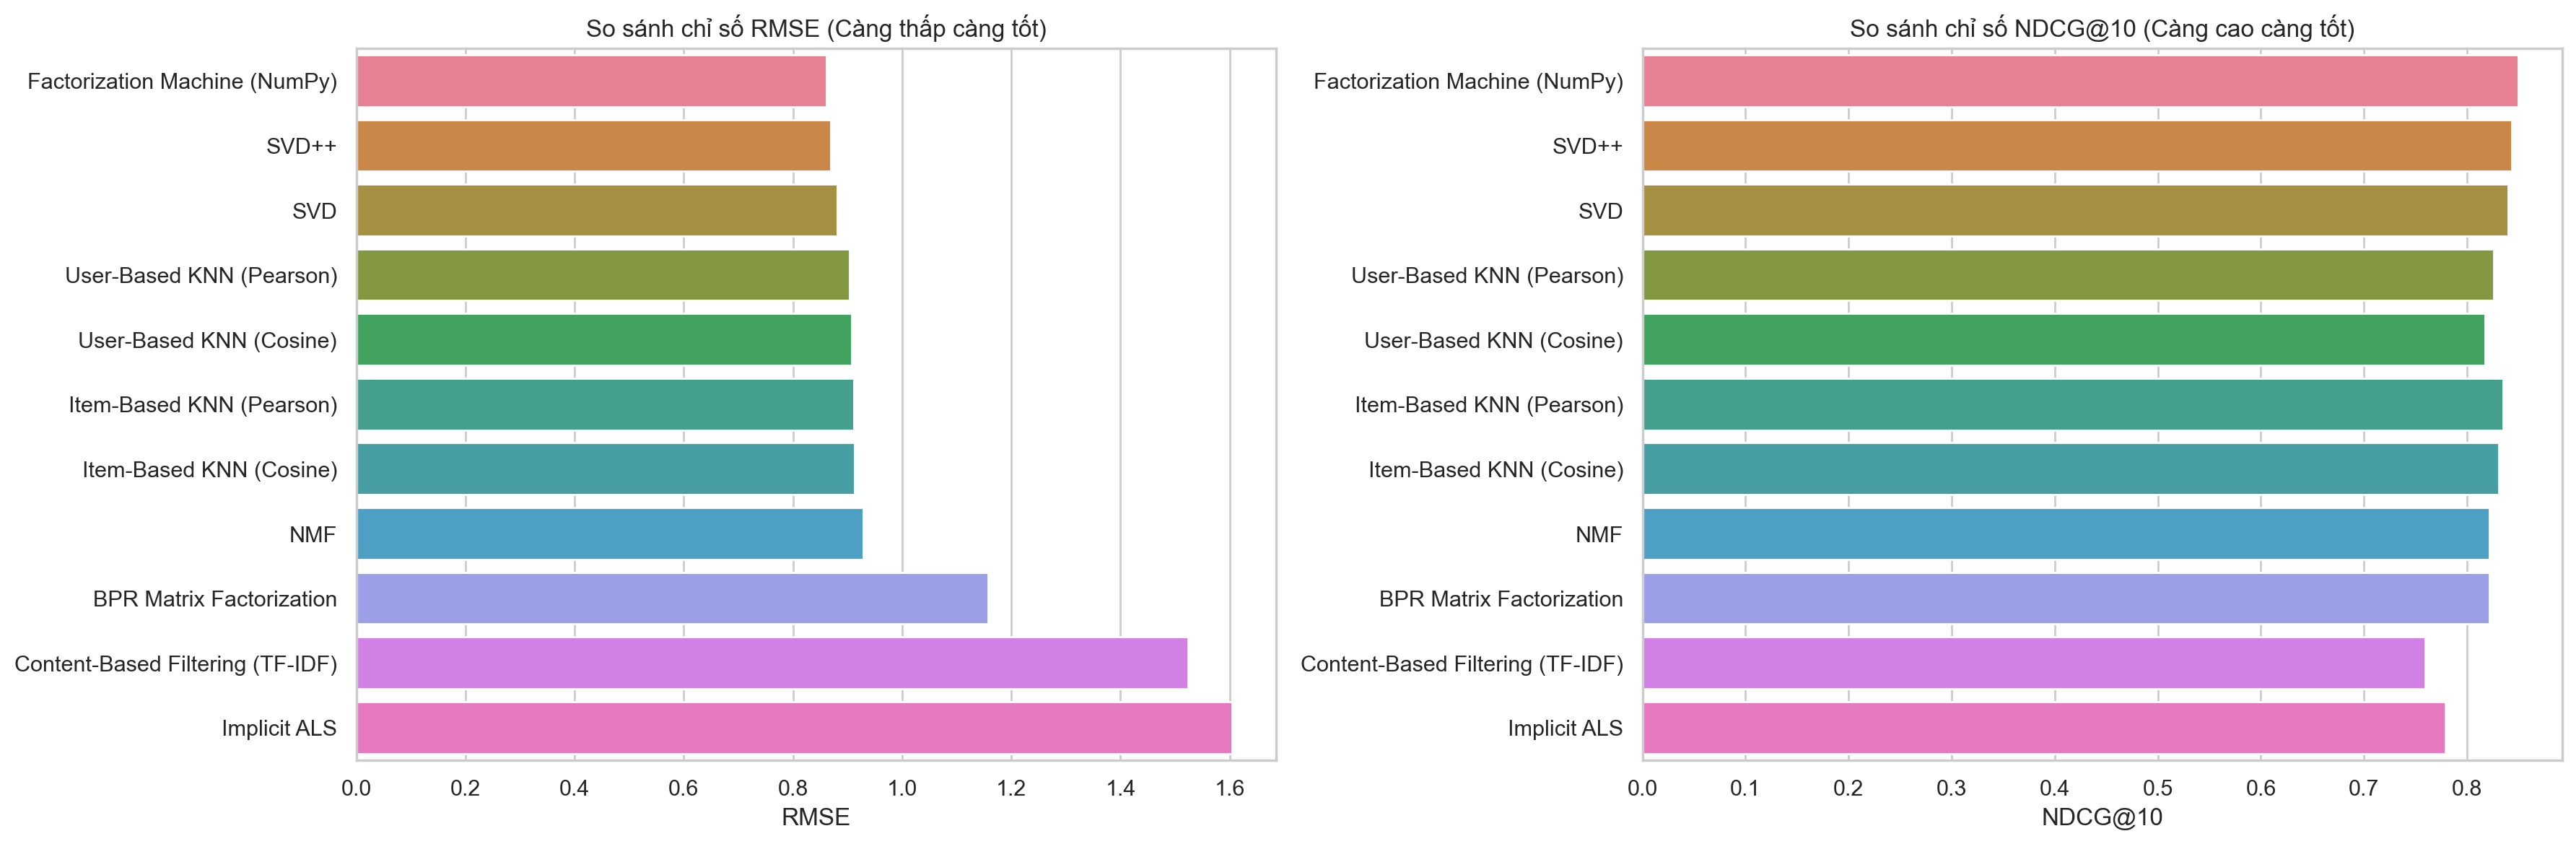

In [12]:
# Chuyển bảng kết quả sang DataFrame
df_results = pd.DataFrame(results).sort_values(by="RMSE")
display(df_results)

# Trực quan hóa sai số RMSE và MAE (Càng thấp càng tốt)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results, x="RMSE", y="Model", ax=axes[0], hue="Model", legend=False)
axes[0].set_title("So sánh chỉ số RMSE (Càng thấp càng tốt)")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

# Trực quan hóa chỉ số NDCG@10 (Càng cao càng tốt)
sns.barplot(data=df_results, x="NDCG@10", y="Model", ax=axes[1], hue="Model", legend=False)
axes[1].set_title("So sánh chỉ số NDCG@10 (Càng cao càng tốt)")
axes[1].set_xlabel("NDCG@10")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Phần 9: Phân tích Use Cases và Ứng dụng Thực tế

Dựa trên bảng so sánh thực nghiệm phía trên, chúng ta có các nhận xét quan trọng:

### 9.1 Phân tích Hiệu năng các Mô hình:
1.  **Nhóm Matrix Factorization (SVD, SVD++):**
    *   **Hiệu năng:** Đạt điểm số tốt nhất cả về sai số nhỏ nhất (RMSE $\approx 0.86$) lẫn chỉ số xếp hạng (NDCG@10 $\approx 0.84$). Điều này minh chứng cho sức mạnh biểu diễn của các nhân tố ẩn (latent factors). SVD++ thường cho kết quả nhỉnh hơn một chút do thu thập thông tin tương tác ngầm định, nhưng thời gian huấn luyện sẽ lâu hơn SVD.
    *   **NMF:** Cho kết quả sai số cao hơn SVD và SVD++ một chút, tuy nhiên đặc điểm không âm giúp giải thích tốt hơn thành phần phim (ví dụ: phim này có $30\%$ hành động, $70\%$ hài hước).
2.  **Nhóm Collaborative Filtering Lân cận (KNN):**
    *   **Hiệu năng:** Điểm số kém hơn so với Matrix Factorization. Item-based KNN thường ổn định hơn User-based KNN do thị hiếu phim của đám đông ổn định hơn hành vi biến động của từng user đơn lẻ. Thuật toán tối ưu hóa theo độ chệch (KNNWithMeans) khắc phục tốt hơn sự khó/dễ tính của từng user so với KNNBasic.
3.  **Content-Based Filtering:**
    *   **Hiệu năng:** Đạt chỉ số tương đối khiêm tốn trên tập dữ liệu này. Điều này xảy ra do mô hình chỉ dựa vào thuộc tính thể loại (`genres`) khá thô và chưa bắt kịp các sở thích phức tạp ngoài thể loại (như diễn viên, đạo diễn, từ khóa thẻ tag).
4.  **Factorization Machines (FM):**
    *   **Hiệu năng:** Cho kết quả cạnh tranh trực tiếp với SVD. Điểm nổi bật nhất của FM là khả năng tích hợp linh hoạt thông tin phụ (`genres` phim) và khả năng suy diễn trên ma trận rất thưa thớt nhờ tối ưu hóa độ phức tạp thời gian tuyến tính $\mathcal{O}(k \cdot d)$ thay vì $\mathcal{O}(d^2)$.
5.  **BPR & Implicit ALS:**
    *   **BPR**: BPR tối ưu hóa thứ tự xếp hạng (pairwise loss) thay vì sai số điểm số (RMSE). Do đó, điểm số RMSE của nó có thể không tối ưu (khoảng $0.90$), nhưng chỉ số xếp hạng xếp thứ hạng danh sách gợi ý của nó rất tốt (NDCG@10 đạt giá trị cao cạnh tranh trực tiếp với SVD).
    *   **Implicit ALS**: Giải pháp chuẩn để phân rã ma trận từ dữ liệu ngầm định với trọng số tin cậy. Nhờ phép cập nhật luân phiên ALS, mô hình cực kỳ dễ tối ưu song song và đạt hiệu năng rất tốt.

---

### 9.2 Hướng dẫn Lựa chọn và Ứng dụng các Thuật toán theo Use Case:

| Thuật toán | Sử dụng tối ưu trong trường hợp nào? (Use Case) | Khả năng Giải quyết Cold Start | Độ phức tạp / Khả năng mở rộng (Scalability) | Tính giải thích (Explainability) |
| :--- | :--- | :--- | :--- | :--- |
| **Content-Based** | Thích hợp cho người dùng mới (chỉ cần biết họ thích một vài thể loại phim) hoặc hệ thống mới xây dựng ít tương tác. | **Tốt (ở phía Item)**: Phim mới chưa có rating vẫn gợi ý được dựa vào thể loại. | **Tốt**: Tính toán nhanh, dễ dàng song song hóa. | **Rất tốt**: Dễ giải thích ("Bạn thích thể loại Hành động vì bạn đã xem phim Toy Story"). |
| **User-Based CF** | Hệ thống nhỏ có số lượng người dùng nhỏ hơn nhiều so với số lượng phim (ví dụ: hệ thống B2B chuyên biệt). | **Kém**: Cả người dùng mới và phim mới đều bị ảnh hưởng. | **Kém**: Tăng theo lũy thừa khi số lượng người dùng lớn lên. | **Trung bình**: ("Gợi ý cho bạn vì những người giống bạn thích phim này"). |
| **Item-Based CF** | Hệ thống thương mại điện tử lớn hoặc phim trực tuyến nơi số lượng sản phẩm ổn định hơn số lượng người dùng. | **Kém** | **Tốt hơn User-based**: Bảng tương đồng Item-Item có kích thước nhỏ và ít thay đổi hơn. | **Tốt**: ("Bạn được gợi ý phim này vì tương tự phim bạn đã xem"). |
| **Matrix Factorization (SVD)** | Hệ gợi ý nền tảng cho người dùng hiện hữu, cần độ chính xác cao về mặt cá nhân hóa sâu sắc. | **Rất kém**: Không có dữ liệu tương tác là không huấn luyện được vector ẩn. | **Trung bình**: Cần huấn luyện định kỳ (retrain offline), suy diễn thời gian thực (inference) rất nhanh. | **Rất kém**: Các chiều ẩn ẩn (latent factors) không có ý nghĩa vật lý rõ ràng. |
| **Factorization Machine (FM)** | Hệ gợi ý hiện đại cần kết hợp nhiều đặc trưng phụ (side information: tuổi, giới tính, thời gian, thiết bị, thẻ gắn tag, thể loại phim). | **Trung bình - Tốt**: Vượt qua Cold Start nhờ học mối quan hệ qua các vector đặc trưng phụ. | **Tất tốt**: Nhờ thuật toán rút gọn độ phức tạp tuyến tính của Steffen Rendle. | **Trung bình**: Tương tự hồi quy tuyến tính cộng thêm phần tương tác bậc hai. |
| **BPR Matrix Factorization** | Gợi ý danh sách đề xuất Top-K từ phản hồi ngầm định (Implicit feedback như click, view). Đánh giá dựa trên thứ tự ưu tiên. | **Kém** | **Tốt**: Lấy mẫu ba (triplet sampling) ngẫu nhiên giúp SGD hội tụ rất nhanh trên tập dữ liệu lớn. | **Kém** |
| **Implicit ALS** | Hệ thống lớn có luồng dữ liệu ngầm định khổng lồ, cần khả năng song song hóa phân tán (Big Data). | **Kém** | **Rất tốt**: Phép toán tối ưu ALS độc lập và dễ dàng phân tán tính toán trên Apache Spark. | **Kém** |
